<a href="https://colab.research.google.com/github/BielPatu/analisador-tendencias-python/blob/main/AnaliseDeDados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import random

frases = [
    "Amei o novo iPhone! #Apple",
    "Promoção imperdível da Nike! #Desconto",
    "Samsung lançou um celular incrível #Tech",
    "Adidas com ofertas incríveis hoje #Sale",
    "Apple anunciou novos recursos #Tecnologia",
    "Não gostei do atendimento da loja #Reclamação",
    "Nike lançou uma nova coleção #Moda",
    "Desconto de 50% em eletrônicos #Promoção",
    "Galaxy S30 é o melhor celular #Samsung",
    "Comprei um tênis novo da Adidas #Fashion"
]

dados = []

# quantidade de posts que deseja gerar
quantidade = 10000

# gera uma quantidade aleatoria das frases dentro da matriz
for i in range(1, quantidade + 1):
    dados.append({
        "id": i,
        "texto": random.choice(frases)
    })

df = pd.DataFrame(dados)

df.to_csv("posts.csv", index=False)

print("CSV criado com sucesso!")

CSV criado com sucesso!


Dados Coletados: [('#samsung', 1006), ('Tecnologia', 3980), ('#reclamação', 996), ('#desconto', 981), ('Moda', 4021), ('Promoções', 2988), ('#moda', 1018), ('#fashion', 1018), ('#sale', 1004), ('#tecnologia', 1012), ('#apple', 982), ('#promoção', 1003), ('#tech', 980)]


/tmp/ipykernel_6594/190081527.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  grafico = sns.barplot(x='Quantidade', y='Categoria/Tag', data=df, palette='viridis')


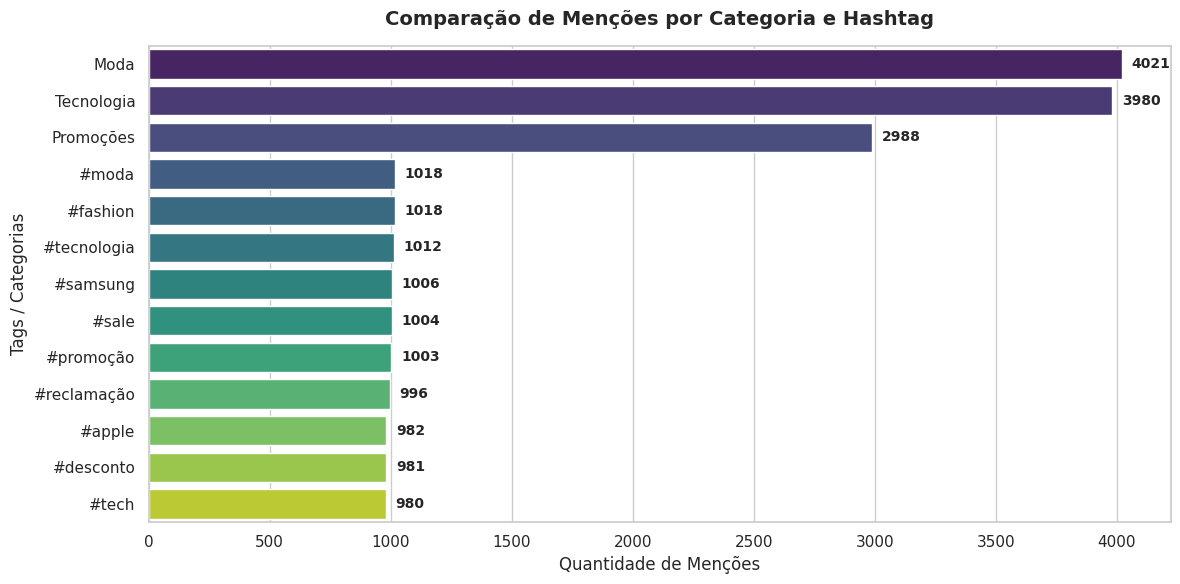

In [ ]:
from pyspark.sql import SparkSession
import re
from operator import add
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Configuração do Spark
spark = SparkSession.builder \
    .appName("AnaliseRedesSociais") \
    .getOrCreate()

dados = spark.read.csv(
    "posts.csv",
    header=True,
    inferSchema=True
)

posts = dados.select("texto").rdd

def mapper(linha):
    texto = str(linha[0]).lower() if linha[0] else ""
    resultados = []

    hashtags = re.findall(r"#\w+", texto)
    for h in hashtags:
        resultados.append((h, 1))

    if any(p in texto for p in ["iphone", "apple", "samsung"]):
        resultados.append(("Tecnologia", 1))

    if any(p in texto for p in ["nike", "adidas"]):
        resultados.append(("Moda", 1))

    if any(p in texto for p in ["promoção", "desconto", "sale"]):
        resultados.append(("Promoções", 1))

    return resultados

# 2. Processamento PySpark e salvamento na variável dados_coletados
dados_coletados = (
    posts
    .flatMap(mapper)
    .reduceByKey(add)
    .collect()  # Coleta os dados para a memória do driver como lista de tuplas
)

# Exibe o resultado no console
print("Dados Coletados:", dados_coletados)


# 3. Geração do Gráfico de Comparação
# Cria o DataFrame a partir da variável que o Spark gerou
df = pd.DataFrame(dados_coletados, columns=['Categoria/Tag', 'Quantidade'])

# Ordena do maior para o menor para a comparação ficar visualmente perfeita
df = df.sort_values(by='Quantidade', ascending=False)

# Configurações visuais do gráfico
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Cria as barras horizontais
grafico = sns.barplot(x='Quantidade', y='Categoria/Tag', data=df, palette='viridis')

# Adiciona os valores numéricos exatos na ponta de cada barra
for index, value in enumerate(df['Quantidade']):
    plt.text(value + (df['Quantidade'].max() * 0.01), index, str(value), va='center', fontsize=10, weight='bold')

# Títulos
plt.title('Comparação de Menções por Categoria e Hashtag', fontsize=14, weight='bold', pad=15)
plt.xlabel('Quantidade de Menções', fontsize=12)
plt.ylabel('Tags / Categorias', fontsize=12)

# Renderiza
plt.tight_layout()
plt.show()